# Behaviour Cloning Evaluation

In [1]:
import sys
import os
import torch
import pandas as pd

if 'google.colab' in sys.modules:
  from google.colab import drive
  drive.mount( "/content/drive")
  if os.path.isdir('drive/MyDrive/Projects/Offline_RL_BSc_Thesis/notebooks'):
    os.chdir('drive/MyDrive/Projects/Offline_RL_BSc_Thesis/notebooks')


project_root = os.path.abspath(os.path.join(os.path.dirname("__file__"), "../../"))
if project_root not in sys.path:
    sys.path.append(project_root)

torch_device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

## Test Evaluation

In [2]:
from src.utils.evaluation import print_model_eval_results, evaluate_model_test_dataset
from src.utils.plotting import plot_confusion_matrix_heatmap

C:\Users\Miro\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Replay Buffer

Model Evaluation results of BC Replay Buffer
accuracy: 0.5760246243125876
balanced_accuracy: 0.5639990217530266
precision_macro: 0.4951480527325235
recall_macro: 0.5639990217530266
f1_macro: 0.5054173976198579
precision_weighted: 0.6531564694733198
recall_weighted: 0.5760246243125876
f1_weighted: 0.5987528319873996
precision_per_class: [0.57143447 0.28431868 0.80856079 0.31627827]
recall_per_class: [0.52072675 0.54125695 0.6056711  0.58834128]
f1_per_class: [0.54490346 0.37280524 0.69256238 0.4113985 ]
confusion_matrix: [[13843  4070  4855  3816]
 [ 1313  5064  1781  1198]
 [ 7851  7497 34304  6986]
 [ 1218  1180  1486  5551]]
classification_report:
  0: {'precision': 0.5714344685242518, 'recall': 0.5207267529340956, 'f1-score': 0.5449034619850814, 'support': 26584.0}
  1: {'precision': 0.28431867946774464, 'recall': 0.5412569474134246, 'f1-score': 0.37280524165347667, 'support': 9356.0}
  2: {'precision': 0.8085607881959176, 'recall': 0.605671104205657, 'f1-score': 0.6925623839134297,

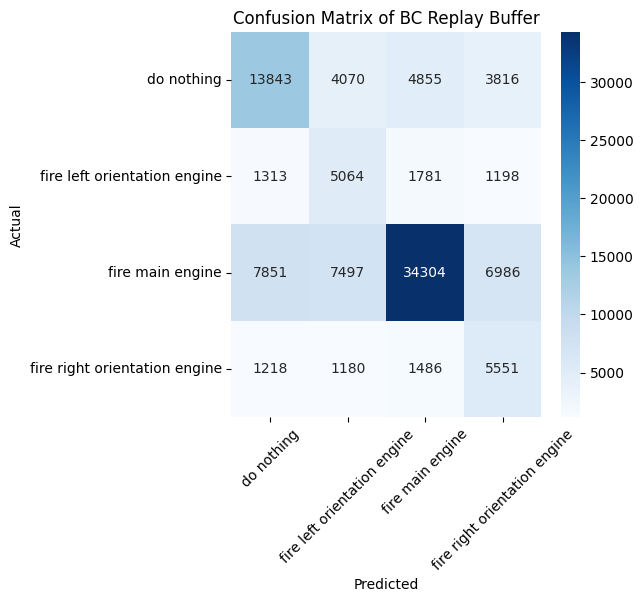

In [3]:
rb_norm_name = 'standard'

rb_test_df = pd.read_parquet('../../data/replay_buffer_episodes/rb_test.parquet').drop(columns=['done', 'episode', 'reward'])
rb_normalization_technique = torch.jit.load(f'../../models/BC/replay_buffer/normalization/{rb_norm_name}_normalization.pt')
#rb_normalization_technique = None
rb_model = torch.jit.load(f'../../models/BC/replay_buffer/BC_{rb_norm_name}.pt')

rb_classificiation_repport_dict, rb_confusion_matrix = evaluate_model_test_dataset(model=rb_model,
                            device=torch_device,
                            test_df=rb_test_df,
                            norm_technique_script=rb_normalization_technique,
                            selected_features=['X', 'Y', 'lv_X', 'lv_Y', 'reward', 'angle', 'angular_velocity', 'leg_1', 'leg_2'])

rb_confusion_matrix_fig = plot_confusion_matrix_heatmap(confusion_matrix=rb_confusion_matrix,
                                                        model_name='BC Replay Buffer',
                                                        f_size=(5,5))

print_model_eval_results(rb_classificiation_repport_dict,
                         model_name='BC Replay Buffer')

### Final Policy

Model Evaluation results of BC Final Policy
accuracy: 0.9794902851375221
balanced_accuracy: 0.9842034384669133
precision_macro: 0.9429312979262384
recall_macro: 0.9842034384669133
f1_macro: 0.9623165579932829
precision_weighted: 0.9806493599078091
recall_weighted: 0.9794902851375221
f1_weighted: 0.9797533921779025
precision_per_class: [0.98541479 0.90028763 0.99520024 0.89082253]
recall_per_class: [0.97208107 0.98894155 0.98165409 0.99413705]
f1_per_class: [0.97870252 0.9425345  0.98838075 0.93964845]
confusion_matrix: [[32903   310   221   414]
 [   27  5634    24    12]
 [  444   309 53080   239]
 [   16     5    11  5426]]
classification_report:
  0: {'precision': 0.9854147948487572, 'recall': 0.9720810683053651, 'f1-score': 0.9787025194086677, 'support': 33848.0}
  1: {'precision': 0.900287631831256, 'recall': 0.9889415481832543, 'f1-score': 0.942534504391468, 'support': 5697.0}
  2: {'precision': 0.9952002399880006, 'recall': 0.9816540908418405, 'f1-score': 0.9883807537613586, 'su

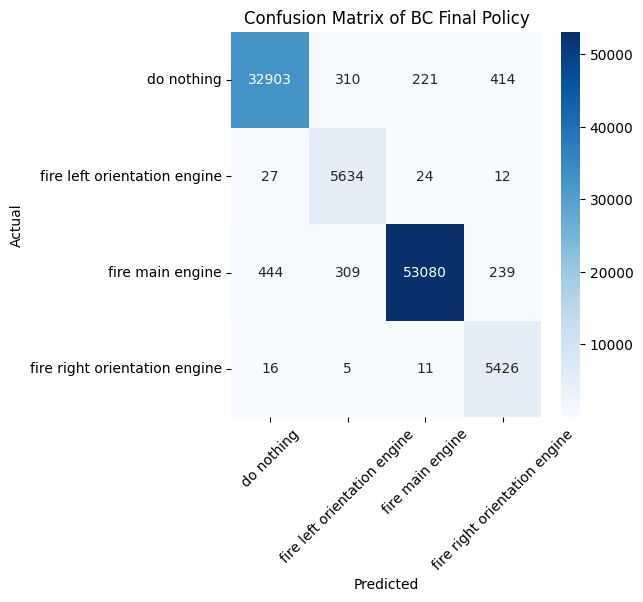

In [4]:
fp_norm_name = 'raw'

fp_test_df = pd.read_parquet('../../data/final_policy_episodes/fp_test.parquet').drop(columns=['done', 'episode', 'reward'])
#fp_normalization_technique = torch.jit.load(f'../../models/BC/final_policy/normalization/{fp_norm_name}_normalization.pt')
fp_normalization_technique = None
fp_model = torch.jit.load(f'../../models/BC/final_policy/BC_{fp_norm_name}.pt')


fp_classificiation_repport_dict, fp_confusion_matrix = evaluate_model_test_dataset(model=fp_model,
                            device=torch_device,
                            test_df=fp_test_df,
                            norm_technique_script=fp_normalization_technique,
                            selected_features=['X', 'Y', 'lv_X', 'lv_Y', 'reward', 'angle', 'angular_velocity', 'leg_1', 'leg_2'])

fp_confusion_matrix_fig = plot_confusion_matrix_heatmap(confusion_matrix=fp_confusion_matrix,
                                                        model_name='BC Final Policy',
                                                        f_size=(5,5))

print_model_eval_results(fp_classificiation_repport_dict,
                         model_name='BC Final Policy')

## Evaluation in the Live Environment for 1000 episodes

In [5]:
import yaml
import warnings

from src.utils.live_env_testing import BC_evaluate_model_in_live_env

warnings.filterwarnings("ignore")
with open('../../config/bc_live_env_elavuation_config.yaml', 'r') as f:
    bc_live_env_config_config = yaml.safe_load(f)

### Replay Buffer

In [6]:
rb_rewards = BC_evaluate_model_in_live_env(
    env_test_params=bc_live_env_config_config,
    model_name='replay_buffer',
    norm_technique=rb_normalization_technique,
    model = rb_model
)

100%|██████████| 1000/1000 [02:06<00:00,  7.89it/s]


### Final Policy

In [7]:
fp_rewards = BC_evaluate_model_in_live_env(
    env_test_params=bc_live_env_config_config,
    norm_technique=fp_normalization_technique,
    model_name='final_policy',
    model = fp_model
)

100%|██████████| 1000/1000 [05:16<00:00,  3.16it/s]


### Accumulated rewards distribution comparison

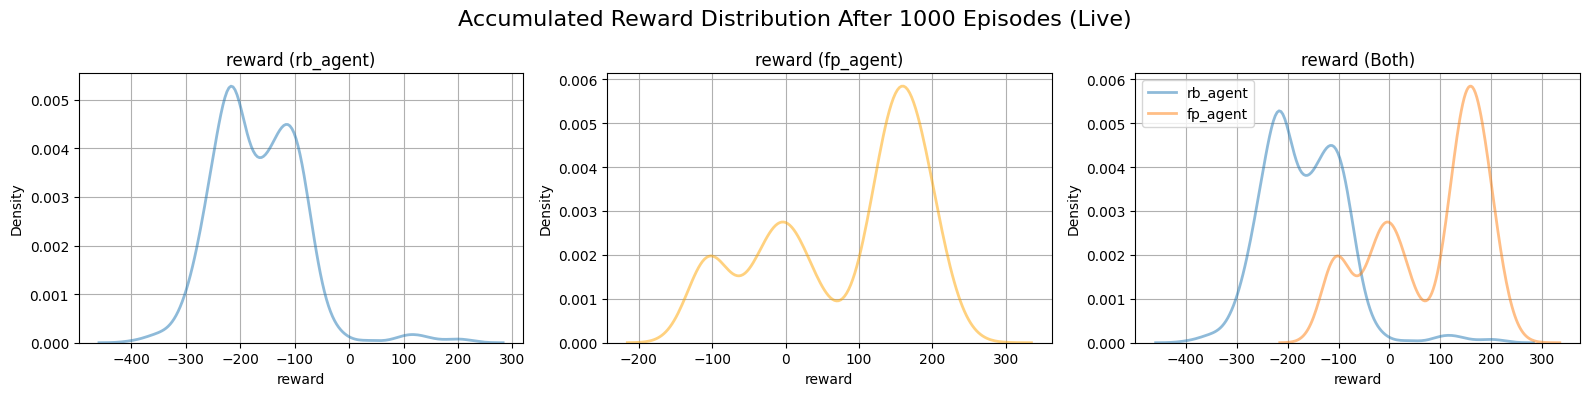

In [8]:
from src.utils.plotting import plot_univariate_analysis


rb_rewards_df = pd.DataFrame(rb_rewards, columns=['reward'])
fp_rewards_df = pd.DataFrame(fp_rewards, columns=['reward'])

rb_fp_combined_fig = plot_univariate_analysis(
        df1_name = 'rb_agent',
        df2_name = 'fp_agent',
        df1=rb_rewards_df,
        df2=fp_rewards_df,
        num_columns=3,
        custom_title='Accumulated Reward Distribution After 1000 Episodes (Live)',
        kde_kwargs={'linewidth': 2, 'alpha': 0.5},
        f_size=(16,4))
rb_fp_combined_fig.savefig('../../plots/liven_env_1000_ep_eval_rb_fp.jpg')